In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima

In [2]:
df = pd.read_csv('../calgary_water_analysis.csv')
df.head()

,Unnamed: 0,date,monthn,month,Daily consumption per capita
0,37,2010-01-01,1,Jan,239.30
1,52,2010-02-01,2,Feb,245.89
2,80,2010-03-01,3,Mar,208.68
3,36,2010-04-01,4,Apr,222.36
4,29,2010-05-01,5,May,241.23


In [3]:
monthly_data = df.set_index(pd.to_datetime(df['date']))['Daily consumption per capita']
model = auto_arima(monthly_data, seasonal=True, m=12)  # yearly seasonality
forecast = model.predict(n_periods=84)  # 7 years * 12 months

In [4]:
print(forecast)

2018-01-01    195.959004
2018-02-01    219.112138
2018-03-01    195.646964
2018-04-01    199.296490
2018-05-01    208.087755
                 ...    
2024-08-01    240.926240
2024-09-01    240.941811
2024-10-01    231.235779
2024-11-01    223.834955
2024-12-01    221.262445
Freq: MS, Length: 84, dtype: float64


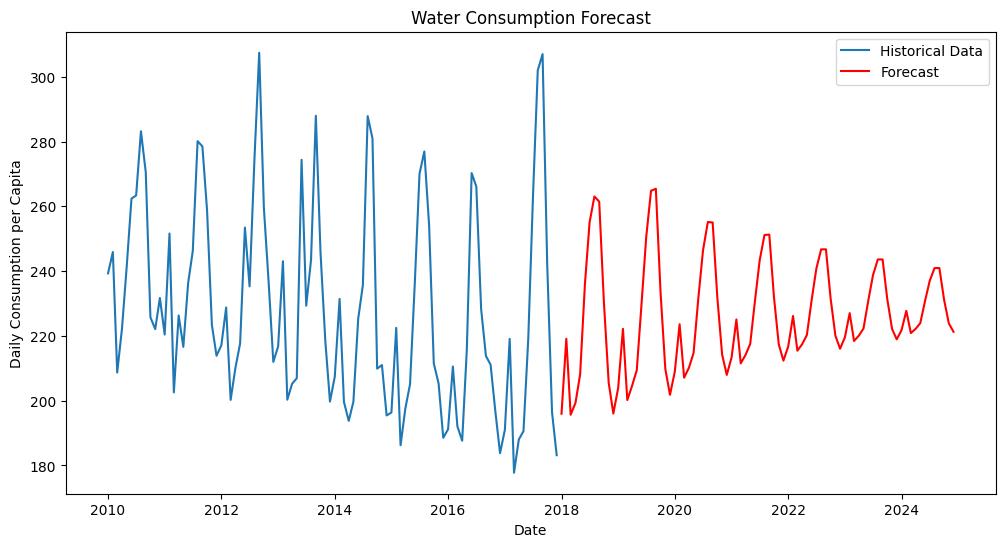

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_data, label='Historical Data')
plt.plot(forecast, label='Forecast', color='red')
plt.title('Water Consumption Forecast')
plt.xlabel('Date')
plt.ylabel('Daily Consumption per Capita')
plt.legend()
plt.show()

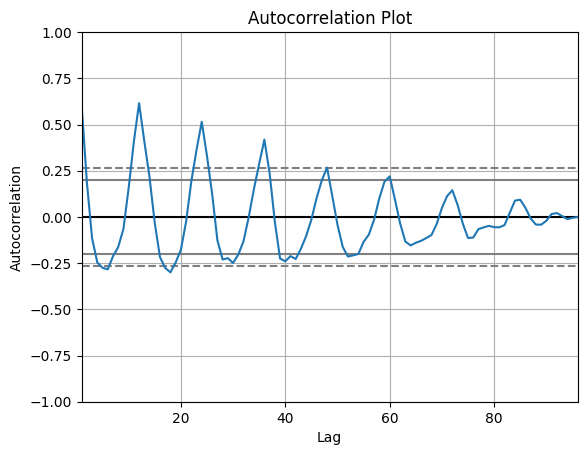

In [6]:
from pandas.plotting import autocorrelation_plot
autocorrelation_plot(monthly_data)
plt.title('Autocorrelation Plot')
plt.show()

In [7]:
import pandas as pd
import numpy as np
from pmdarima import auto_arima
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

df['date'] = pd.to_datetime(df['date'])
ts = df.set_index('date')['Daily consumption per capita'].asfreq('MS')  
ts = ts.dropna()  

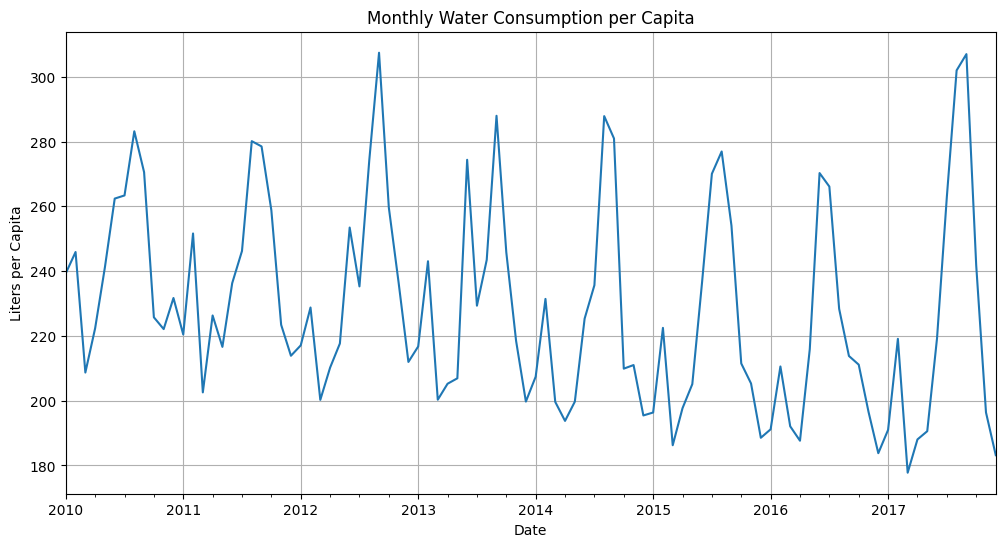

In [8]:
plt.figure(figsize=(12, 6))
ts.plot(title='Monthly Water Consumption per Capita')
plt.ylabel('Liters per Capita')
plt.xlabel('Date')
plt.grid(True)
plt.show()

In [9]:
from statsmodels.tsa.stattools import adfuller

def test_stationarity(series):
    result = adfuller(series)
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    if result[1] <= 0.05:
        print("Data is stationary (reject H0)")
    else:
        print("Data is non-stationary (fail to reject H0)")

test_stationarity(ts)

ADF Statistic: -1.5077216523728272
p-value: 0.5296881483245388
Data is non-stationary (fail to reject H0)


In [10]:
ts_diff = ts.diff().dropna()

test_stationarity(ts_diff)

ADF Statistic: -6.737692052888488
p-value: 3.176627592738617e-09
Data is stationary (reject H0)


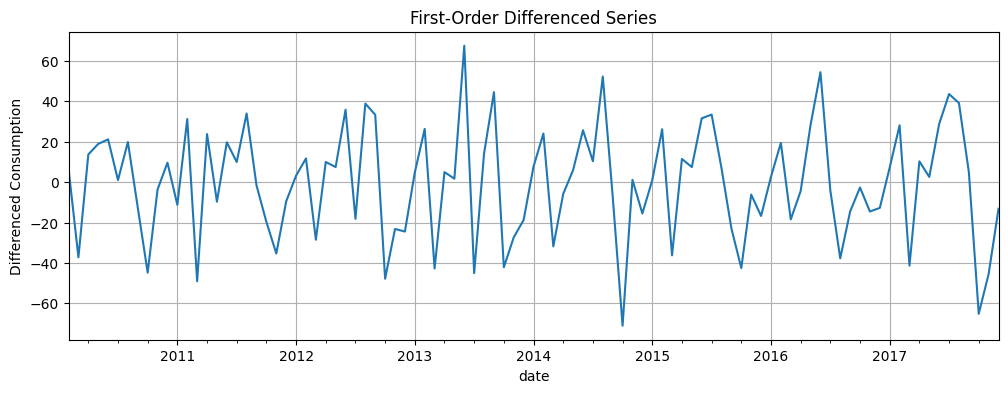

In [11]:
plt.figure(figsize=(12, 4))
ts_diff.plot(title='First-Order Differenced Series')
plt.ylabel('Differenced Consumption')
plt.grid(True)
plt.show()

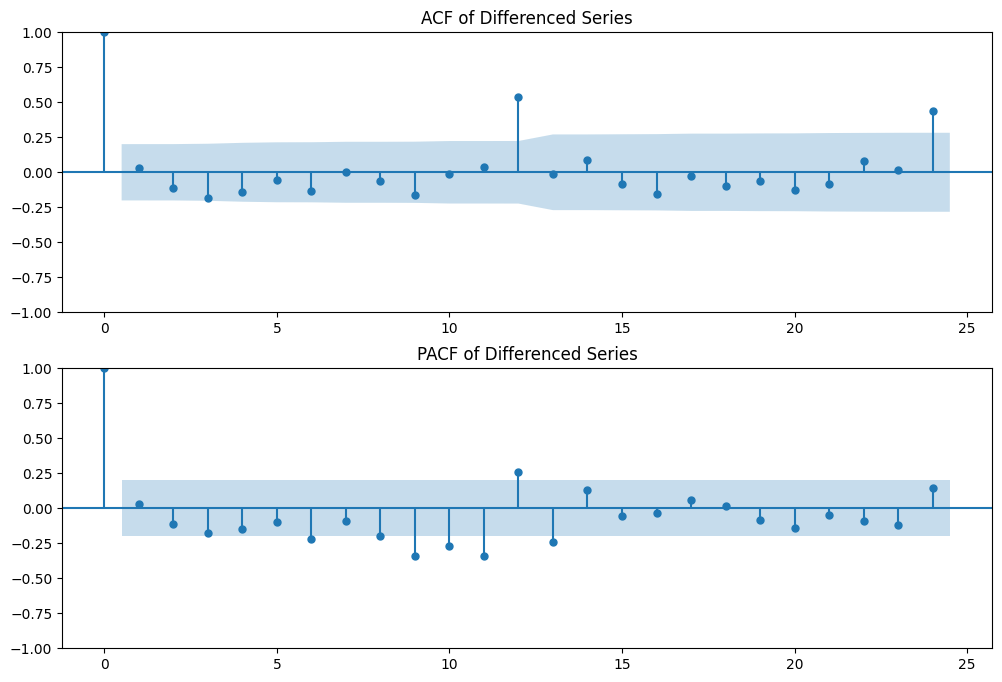

In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(ts_diff, lags=24, ax=ax1, title='ACF of Differenced Series')
plot_pacf(ts_diff, lags=24, ax=ax2, title='PACF of Differenced Series', method='ywm')
plt.show()

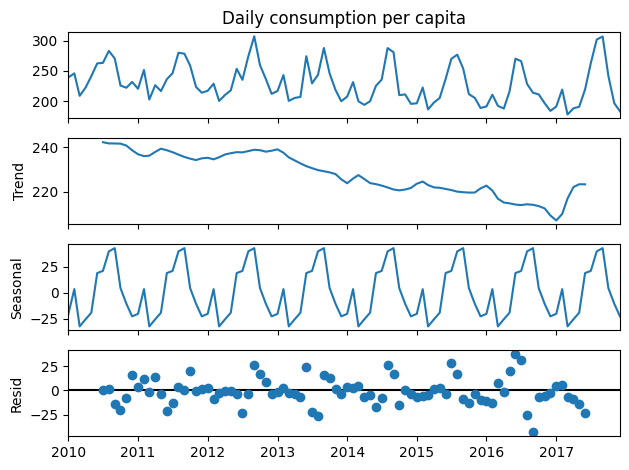

In [13]:
# Plot seasonal decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(ts, model='additive', period=12)
result.plot()
plt.show()

In [22]:
# Seasonal ARIMA with m=12 (monthly data)
model = auto_arima(
    ts,
    d=0,                    # First-order differencing
    seasonal=True,
    m=12,                   # Monthly seasonality
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    D=1,                    # Seasonal differencing (if needed)
    trace=True
)

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=5.86 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=762.409, Time=0.06 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=741.597, Time=2.14 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=inf, Time=1.97 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=761.773, Time=0.08 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=750.153, Time=0.05 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=730.189, Time=2.96 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=inf, Time=8.60 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=4.95 sec
 ARIMA(0,0,0)(2,1,0)[12] intercept   : AIC=741.774, Time=2.93 sec
 ARIMA(2,0,0)(2,1,0)[12] intercept   : AIC=725.849, Time=2.95 sec
 ARIMA(2,0,0)(1,1,0)[12] intercept   : AIC=731.087, Time=2.87 sec
 ARIMA(2,0,0)(2,1,1)[12] intercept   : AIC=inf, Time=7.98 sec
 ARIMA(2,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=7.06 sec
 ARIMA(3,0,0)(2,1,0)[12] intercept   : AIC=727.759, Time=

In [14]:
stepwise_model = auto_arima(ts, start_p=0, start_q=0,
                            max_p=3, max_q=3, m=12,
                            start_P=0, seasonal=True,
                            d=1, D=1, trace=True,
                            error_action='ignore',  
                            suppress_warnings=True, 
                            stepwise=True)
print(stepwise_model.summary())


Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=inf, Time=2.34 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=767.613, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=761.324, Time=1.18 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=4.46 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=769.440, Time=0.06 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=749.079, Time=2.20 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=8.47 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=inf, Time=4.46 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=748.287, Time=1.48 sec
 ARIMA(0,1,0)(1,1,0)[12]             : AIC=759.451, Time=1.13 sec
 ARIMA(0,1,0)(2,1,1)[12]             : AIC=inf, Time=5.48 sec
 ARIMA(0,1,0)(1,1,1)[12]             : AIC=inf, Time=3.10 sec
 ARIMA(0,1,1)(2,1,0)[12]             : AIC=738.905, Time=5.94 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=inf, Time=2.06 sec
 ARIMA(0,1,1)(2,1,1)[12]             : AIC=738.922, Time=5.18

In [15]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    ts,
    order=(2, 0, 0),                # (p,d,q)
    seasonal_order=(2, 1, 0, 12),    # (P,D,Q,m)
    trend='c'                        # Include constant
)
results = model.fit()
print(results.summary())

 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            6     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  3.75806D+00    |proj g|=  1.02021D-01

At iterate    5    f=  3.73878D+00    |proj g|=  1.78923D-02

At iterate   10    f=  3.72133D+00    |proj g|=  5.28593D-03

At iterate   15    f=  3.71906D+00    |proj g|=  3.36846D-02

At iterate   20    f=  3.71796D+00    |proj g|=  1.54686D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    6     21     23      1     0     0   8.888D-07   3.718D+00
  F =   3.7179620003480536     

CONVERG

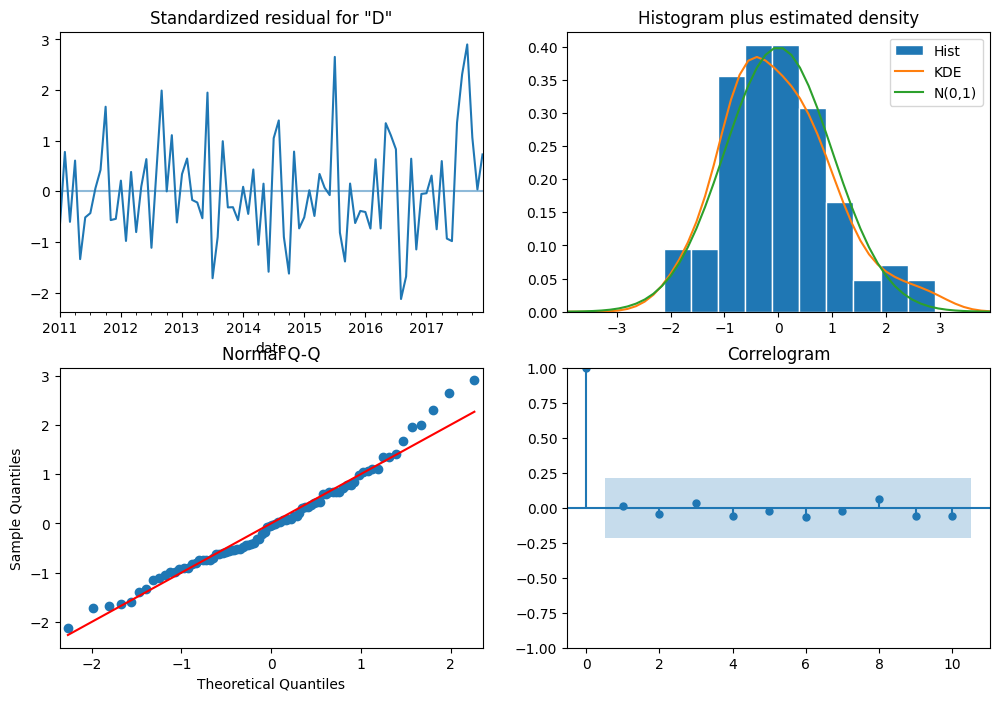

In [16]:
results.plot_diagnostics(figsize=(12, 8))
plt.show()

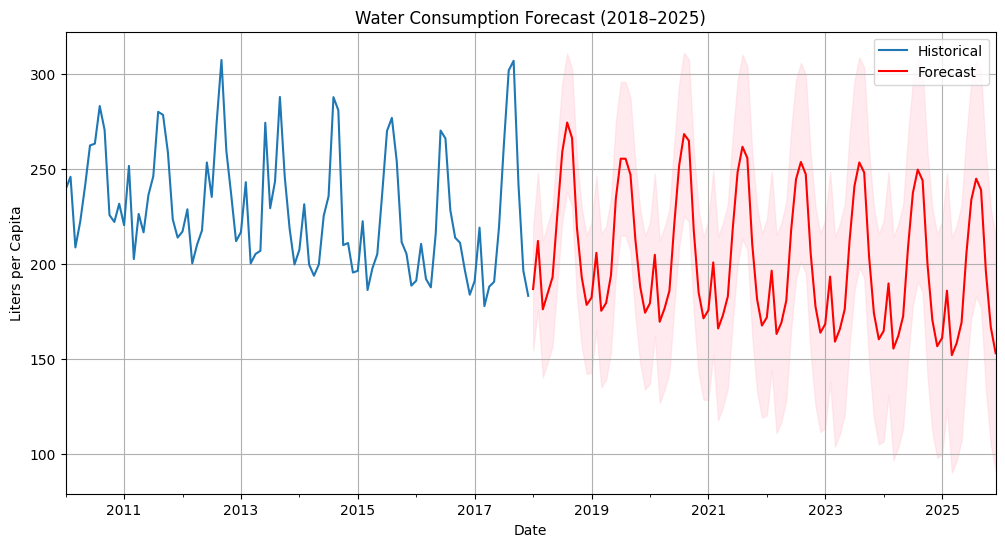

In [19]:
# Forecast 84 months (8 years)
forecast_steps = 96 
forecast = results.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# Plot results
plt.figure(figsize=(12, 6))
ts.plot(label='Historical')
forecast_mean.plot(label='Forecast', color='red')
plt.fill_between(conf_int.index, conf_int.iloc[:,0], conf_int.iloc[:,1], color='pink', alpha=0.3)
plt.title('Water Consumption Forecast (2018–2025)')
plt.xlabel('Date')
plt.ylabel('Liters per Capita')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
results.save('monthly_sarimaz.pickle')


from statsmodels.tsa.statespace.sarimax import SARIMAX
loaded_model = SARIMAX.load('monthly_sarimaz.pickle')

# Plot loaded model results
plt.figure(figsize=(12, 6))         

In [28]:
historical_df = ts.to_frame(name='water_consumption')

forecast_df = pd.concat([forecast_mean, conf_int], axis=1)
forecast_df.columns = ['water_consumption', 'Lower CI', 'Upper CI']

combined_df = pd.concat([historical_df, forecast_df], axis=0)

combined_df.to_csv('water_consumption_forecast.csv', index=True)
combined_df.shape

(192, 3)